In [ ]:
# Sel 1: Load Library & Data Mentah
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/raw/all_locations.csv")
figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)
df.head()

,time,location,wave_height,wind_speed_10m,precipitation,visibility,ocean_current_velocity,sea_surface_temperature
0,2026-05-20T00:00,Pacitan,1.60,3.5,0.0,11460.0,0.5,28.0
1,2026-05-20T01:00,Pacitan,1.60,3.0,0.0,14120.0,0.5,28.0
2,2026-05-20T02:00,Pacitan,1.60,4.0,0.0,14200.0,0.5,28.0
3,2026-05-20T03:00,Pacitan,1.58,4.1,0.0,14200.0,0.5,28.0
4,2026-05-20T04:00,Pacitan,1.58,2.9,0.0,11640.0,0.5,28.0


In [ ]:
# Sel 2: Analisis Missing Value dan Struktur data
print("--- Check Missing Values ---")
print(df.isnull().sum())
print("\n--- Ringkasan Struktur Data ---")
df.info()

--- Check Missing Values ---
time                         0
location                     0
wave_height                168
wind_speed_10m               0
precipitation                0
visibility                   0
ocean_current_velocity       0
sea_surface_temperature      0
dtype: int64

--- Ringkasan Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time                     4368 non-null   object 
 1   location                 4368 non-null   object 
 2   wave_height              4200 non-null   float64
 3   wind_speed_10m           4368 non-null   float64
 4   precipitation            4368 non-null   float64
 5   visibility               4368 non-null   float64
 6   ocean_current_velocity   4368 non-null   float64
 7   sea_surface_temperature  4368 non-null   float64
dtypes: float64(6), object(2)
m

In [25]:
# Sel 3: Statistik Deskriptif 
df.describe()

,wave_height,wind_speed_10m,precipitation,visibility,ocean_current_velocity,sea_surface_temperature
count,4200.000000,4368.000000,4368.000000,4368.000000,4368.000000,4368.000000
mean,0.550452,6.798352,0.168956,9220.022894,0.782326,30.265636
std,0.544573,4.094419,0.404557,5553.847032,1.080217,1.187168
min,0.020000,0.000000,0.000000,100.000000,0.000000,27.600000
25%,0.100000,3.700000,0.000000,5180.000000,0.200000,29.000000
50%,0.220000,6.000000,0.000000,8720.000000,0.400000,30.600000
75%,1.100000,9.300000,0.200000,12600.000000,0.900000,31.200000
max,1.920000,25.700000,5.500000,29020.000000,8.600000,32.300000


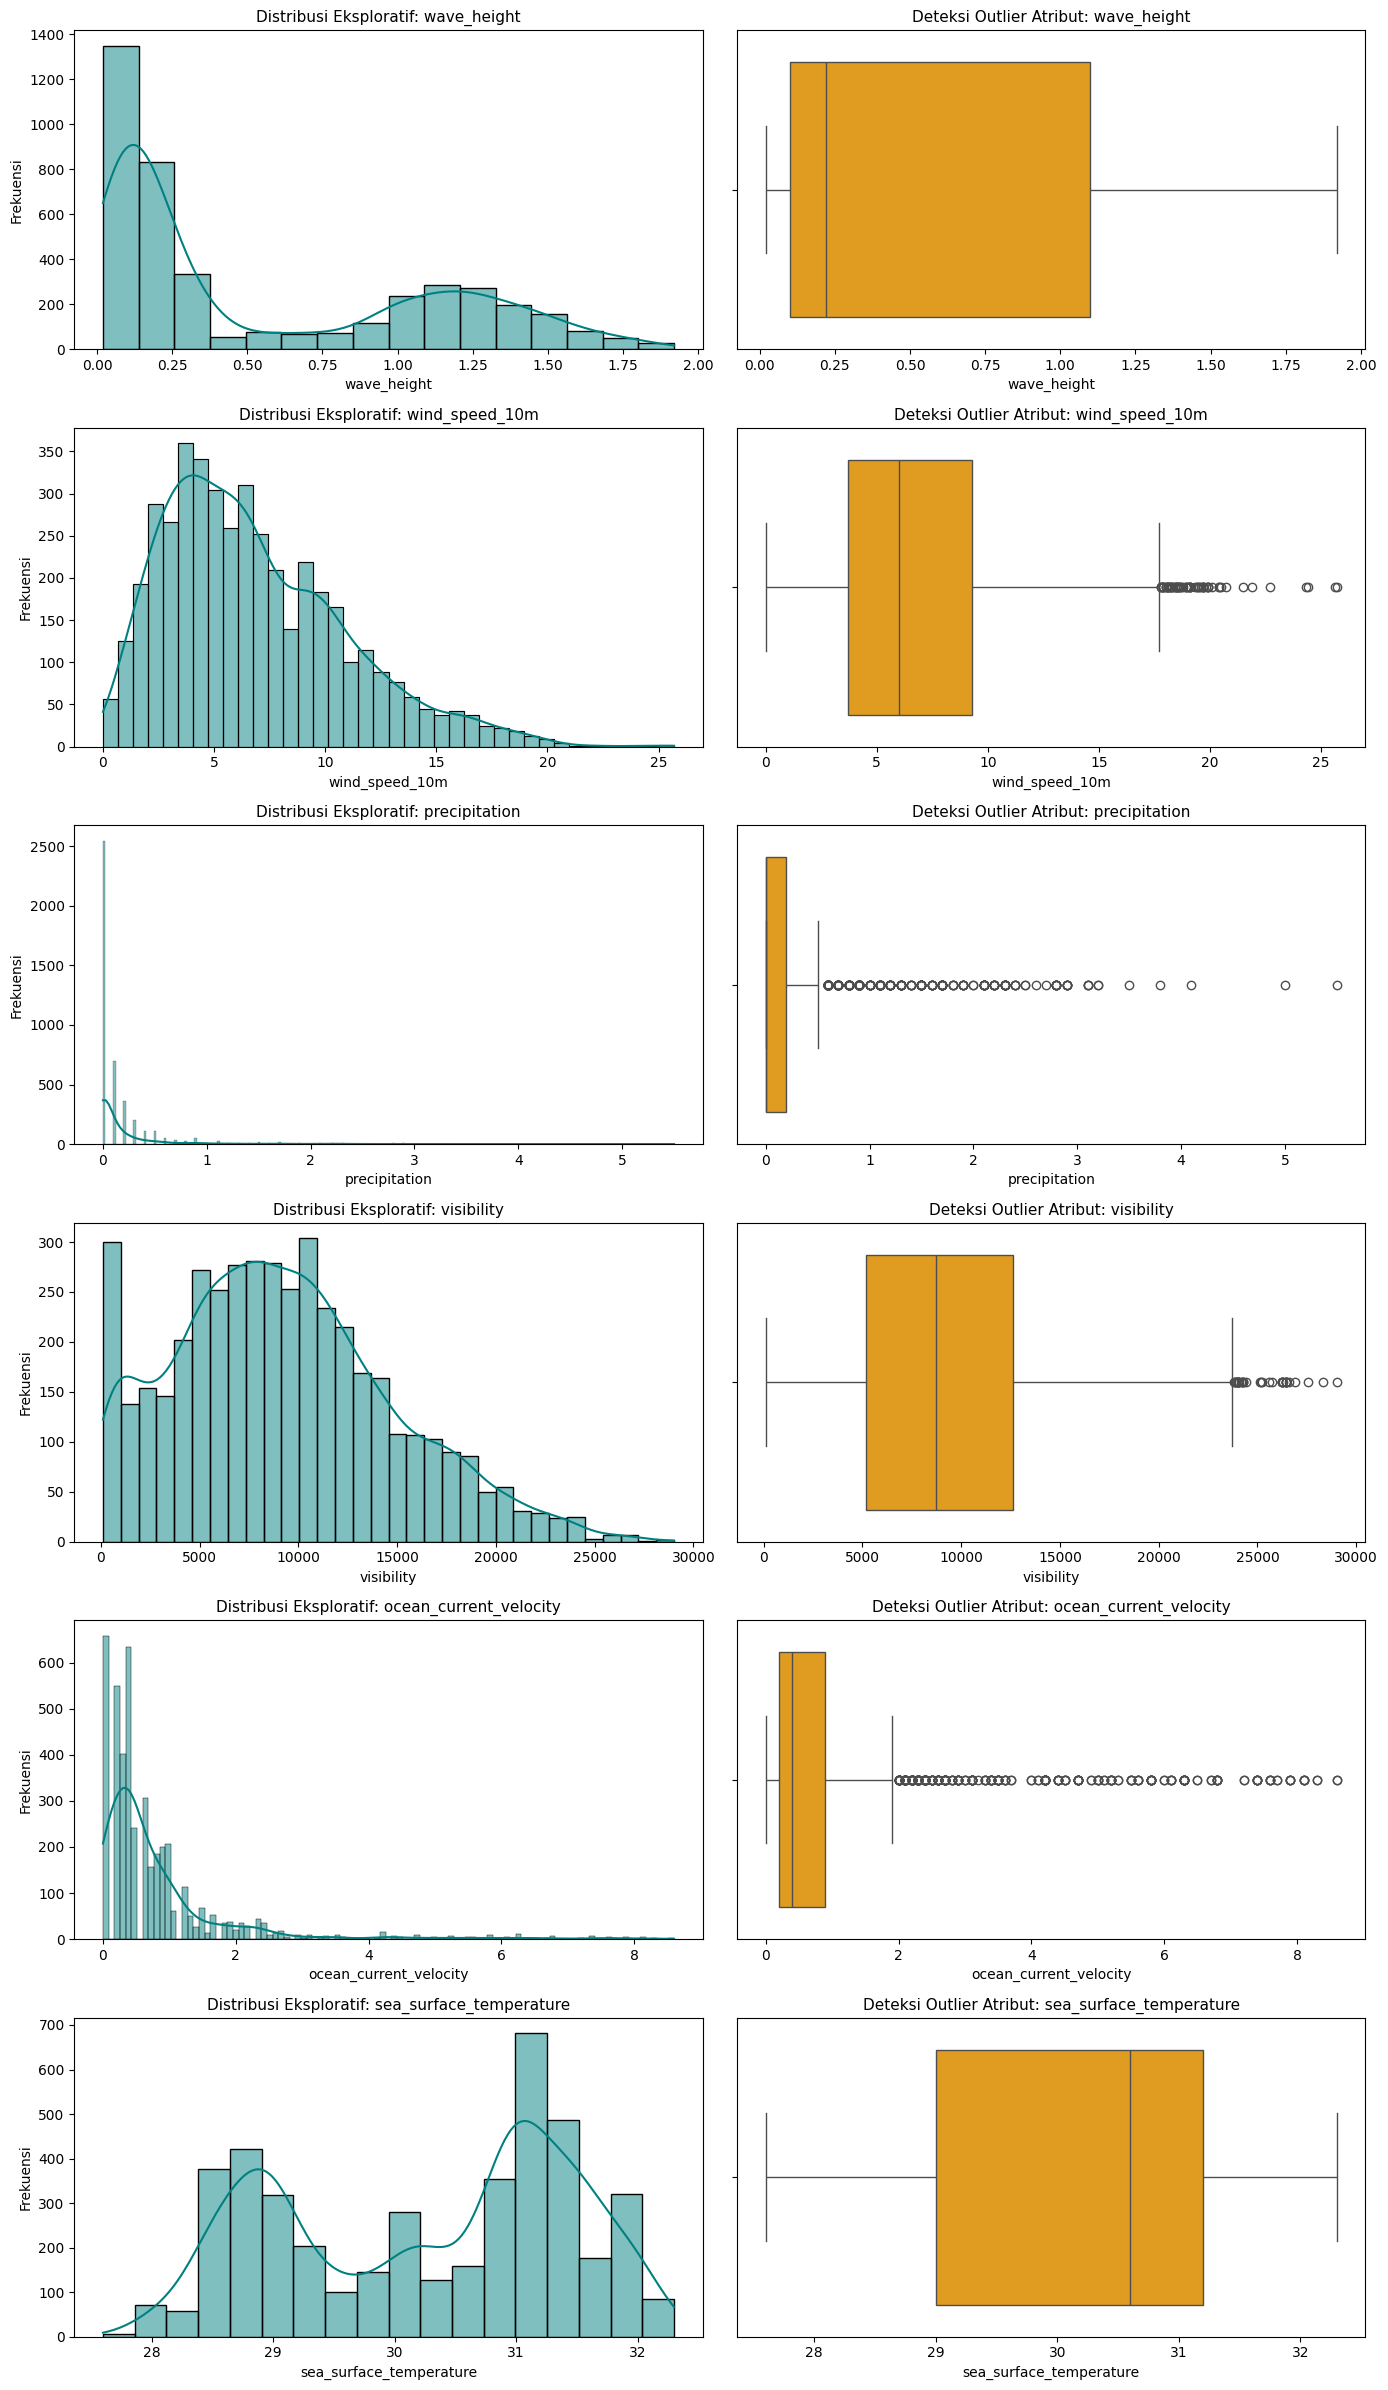

In [26]:

# Sel 4: Visualisasi Lengkap (6 Fitur Numerik) - Distribusi & Outlier
features = ["wave_height", "wind_speed_10m", "precipitation", "visibility", "ocean_current_velocity", "sea_surface_temperature"]

fig, axes = plt.subplots(6, 2, figsize=(14, 24))
for i, col in enumerate(features):
    # Histogram Distribusi Data
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="teal")
    axes[i, 0].set_title(f"Distribusi Eksploratif: {col}", fontsize=11)
    axes[i, 0].set_ylabel("Frekuensi")
    
    # Boxplot Deteksi Nilai Outlier
    sns.boxplot(x=df[col], ax=axes[i, 1], color="orange")
    axes[i, 1].set_title(f"Deteksi Outlier Atribut: {col}", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "distribusi_dan_outlier.png"), dpi=300)
plt.show()

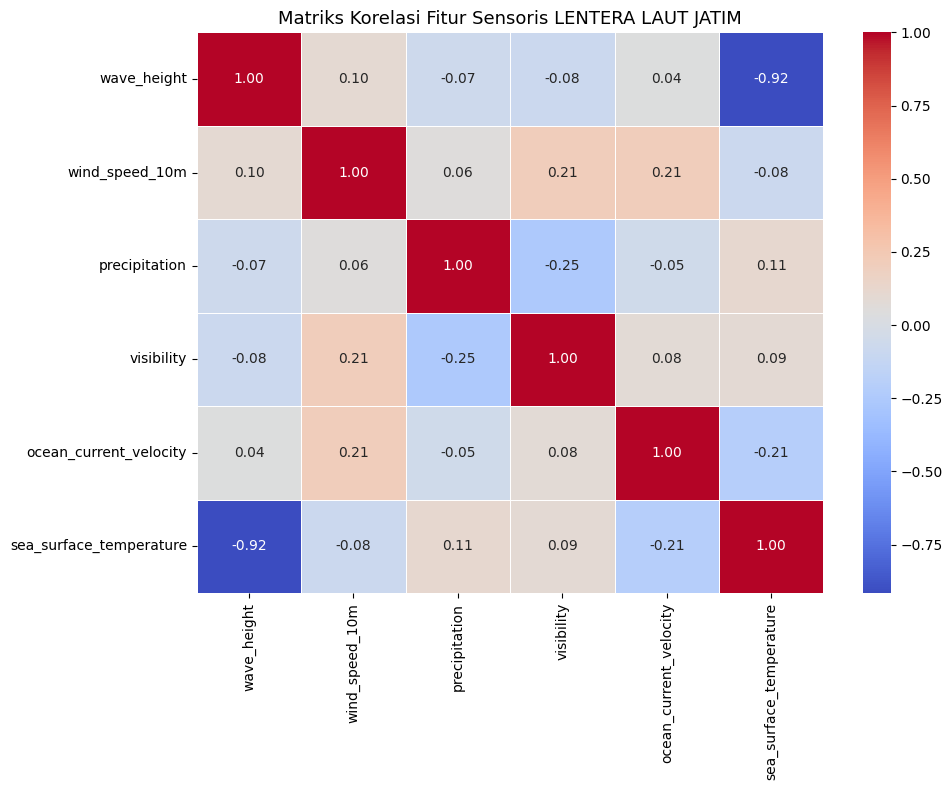

In [27]:
# Sel 5: Heatmap Korelasi Linear Antar Fitur Lingkungan
plt.figure(figsize=(10, 8))
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur Sensoris LENTERA LAUT JATIM", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "heatmap_korelasi.png"), dpi=300)
plt.show()